# OpenCV-Python
### 1. OpenCV-Python 기초
1.1 이미지 읽고 출력하기
``` python
cv2.namedWindow(win_name[, flag])
    - cv2.WINDOW_AUTOSIZE : defalut, 크기고정
    - cv2.WINDOW_NORMAL : 크기조절 가능
cv2.moveWindow(win_name, y, x)
cv2.resizeWindow(win_name, width, height)
cv2.waitKey([delay])  # mili-second, default:0
cv2.destroyWindow(win_name)
cv2.destroyAllWindows()
```

In [21]:
import cv2
import numpy as np

image = np.zeros((200, 400), np.uint8)
image.fill(255)
cv2.namedWindow("window", cv2.WINDOW_NORMAL) # 크기조절 가능
cv2.moveWindow("window", 100, 100)
cv2.resizeWindow("window", 400, 200) # 크기 조절
cv2.imshow("window", image)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [2]:
import cv2

#image = cv2.imread('images/lena.jpg', cv2.IMREAD_COLOR)
image = cv2.imread('images/lena.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)

print('ndim =', image.ndim)
print('shape =', image.shape)
print('dtype =', image.dtype)
print(image[100:110, 200:210])

cv2.waitKey(0)
cv2.destroyAllWindows()

ndim = 2
shape = (512, 512)
dtype = uint8
[[146 143 145 132 147 144 142 139 132 138]
 [138 138 143 151 137 144 139 139 138 138]
 [132 139 153 140 133 136 143 138 137 128]
 [137 146 138 125 132 145 139 142 130 128]
 [149 139 130 137 140 145 136 133 132 141]
 [141 139 134 149 149 137 132 127 140 140]
 [142 148 139 142 144 138 146 135 131 130]
 [151 146 136 131 142 144 149 135 126 132]
 [147 131 135 138 147 139 128 125 134 138]
 [135 132 149 142 134 128 122 135 138 129]]


1.2 트랙바 이벤트 사용
```python
cv2.createTrackbar(trackbar_name, win_name, start_value, max_value, onChange)
```

In [22]:
import cv2
import numpy as np

def onChange(value):
    global image
    image[:] = value
    cv2.imshow("window", image)

image = np.zeros((300, 400), np.uint8)
cv2.imshow("window", image)
cv2.createTrackbar("trackbar", "window", 0, 255, onChange)

cv2.waitKey(0)
cv2.destroyAllWindows()

1.3 도형 그리기

In [23]:
import cv2
import numpy as np

b, g, r = (255,0,0), (0,255,0), (0,0,255)
image = np.zeros((400, 600, 3), np.uint8)
image[:] = 255

cv2.line(image, (50, 50), (250, 150), r, 2, cv2.LINE_AA)
cv2.rectangle(image, (50, 50), (250, 150), g, 2, cv2.LINE_AA)
cv2.rectangle(image, (250, 270), (350, 350), r, -1, cv2.LINE_AA)
cv2.circle(image, (100, 100), 50, b, 5, cv2.LINE_AA)
cv2.circle(image, (200, 200), 50, r, -1, cv2.LINE_AA) # 원의 내부 채움
cv2.putText(image, 'drawing...', (250, 250), cv2.FONT_HERSHEY_COMPLEX, 0.8, (0,0,0))

cv2.imshow("window", image)

cv2.waitKey(0)
cv2.destroyAllWindows()

1.4 ROI 선택하기

In [1]:
import cv2

#image = cv2.imread('images/lena.jpg', cv2.IMREAD_COLOR)
image = cv2.imread('images/lena.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)

roi = cv2.selectROI(image) # roi = (x, y, width, height) # 마우스로 선택 후 ENTER를 입력해야 함
print(roi)
x, y, w, h = roi
if w == 0 or h == 0 : raise Exception('ROI 선택 없음')
img_roi = image[y:y+h, x:x+w]
cv2.imshow('roi', img_roi)

cv2.waitKey(0)
cv2.destroyAllWindows()

(241, 239, 132, 94)


1.5 채널 분리 및 병합
```python
b, g, r = cv2.split(image)
image = cv2.merge([b, g, r]) # 주의: 채널의 순서는 b, g, r임
```

In [2]:
import cv2

image = cv2.imread('images/lena.jpg', cv2.IMREAD_COLOR)
cv2.imshow('image', image)

b, g, r = cv2.split(image)
cv2.imshow('blue', b)
cv2.imshow('green', g)
cv2.imshow('red', r)
image2 = cv2.merge([b, g, r]) # 주의: 채널의 순서는 b, g, r임
cv2.imshow('image2', image2)

cv2.waitKey(0)
cv2.destroyAllWindows()

1.6 컬러공간 변환
```python
cv2.cvtColor(src_image, code) -> dst_image
    - cv2.COLOR_BGR2GRAY      - cv2.COLOR_GRAY2BGR
    - cv2.COLOR_BGR2HSV       - cv2.COLOR_HSV2BGR
    - cv2.COLOR_BGR2YCrCb     - cv2.COLOR_YCrCb2BGR
```

In [3]:
import cv2

image = cv2.imread('images/lena.jpg', cv2.IMREAD_COLOR)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
yCrCv = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
cv2.imshow('gray', gray)
cv2.imshow('yCrCv', yCrCv)
cv2.imshow('hsv', hsv)

cv2.waitKey(0)
cv2.destroyAllWindows()

1.7 영상의 크기변환 및 회전
```python
cv2.resize(src_image, dst_image_size[, fx, fy]) -> dst_image
cv2.rotate(src_image, rotate_code) -> dst_image
cv2.getRotationMatrix2D(center, angle, scale) -> M
cv2.warpAffine(src_image, M, dst_image_size) -> dst_image
```

In [4]:
import cv2

image = cv2.imread('images/lena.jpg', cv2.IMREAD_COLOR)
if image is None: raise Exception('이미지 파일 읽기 오류')
    
img1 = cv2.resize(image, dsize=(300, 200))
img2 = cv2.resize(image, dsize=(0, 0), fx=0.5, fy=0.6)

img3 = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

center = (image.shape[0]/2, image.shape[1]/2)
M = cv2.getRotationMatrix2D(center, -30, 0.8)
img4 = cv2.warpAffine(image, M, dsize=(image.shape[0], image.shape[1]))

cv2.imshow('img1', img1)
cv2.imshow('img2', img2)
cv2.imshow('img3', img3)
cv2.imshow('img4', img4)

cv2.waitKey(0)
cv2.destroyAllWindows()

1.8 비트연산을 이용한 로고의 합성

    - 이미지와 로고를 읽는다.  
    - 로고를 이진화한다.  
    - 전경통과마스크와 배경통과마스크를 만든다.  
    - 전경통과마스크를 이용하여 로고의 전경부분만 추출한다.  
    - 이미지에 ROI를 설정한다.  
    - 배경통과마스크를 이용하여 이미지의 배경부분만 추출한다.  
    - 추출된 배경과 전경을 합성한다.  
    - 이미지의 ROI부분을 합성된 이미지로 교체한다.  

In [3]:
import cv2

image = cv2.imread('images/lena.jpg', cv2.IMREAD_COLOR)
logo = cv2.imread('images/opencv-logo.jpg', cv2.IMREAD_COLOR)
cv2.imshow('logo', logo)
rows, cols, channel = image.shape
r, c, channel = logo.shape
print(f"logo : rows = {r}, cols = {c}")
ret, masks = cv2.threshold(logo, 20, 255, cv2.THRESH_BINARY)
masks = cv2.split(masks)
fg_pass_mask = cv2.bitwise_or(masks[0], masks[1])
fg_pass_mask = cv2.bitwise_or(masks[2], fg_pass_mask)
bg_pass_mask = cv2.bitwise_not(fg_pass_mask)
cv2.imshow('fg_pass_mask', fg_pass_mask)
cv2.imshow('bg_pass_mask', bg_pass_mask)

sy, sx = rows//2-r//2, cols//2-c//2
roi = image[sy:sy+r, sx:sx+c]
src_bg = cv2.bitwise_and(roi, roi, mask=bg_pass_mask)
cv2.imshow('src_bg', src_bg)
src_fg = cv2.bitwise_and(logo, logo, mask=fg_pass_mask)
cv2.imshow('src_fg', src_fg)
dst = cv2.add(src_bg, src_fg)
cv2.imshow('dst', dst)

image[sy:sy+r, sx:sx+c] = dst
cv2.imshow('result', image)

cv2.waitKey(0)
cv2.destroyAllWindows()

logo : rows = 308, cols = 250


---
### 2. 바이너리 이미지 관련
2.1 히스토그램(histogram) 계산 및 출력
```python
cv2.calcHist(images, channels, mask, hist_sizes, ranges) -> hist
    - images : 이미지 배열
    - channels : 채널번호 정수배열, 그레이 이미지는 [0]
    - mask : 히스토그램을 계산한 부분, None이면 전체 이미지
    - hist_sizes : bin 크기에 대한 정수배열
    - ranges : 화소값의 범위, 일반적으로 [0,255]
```

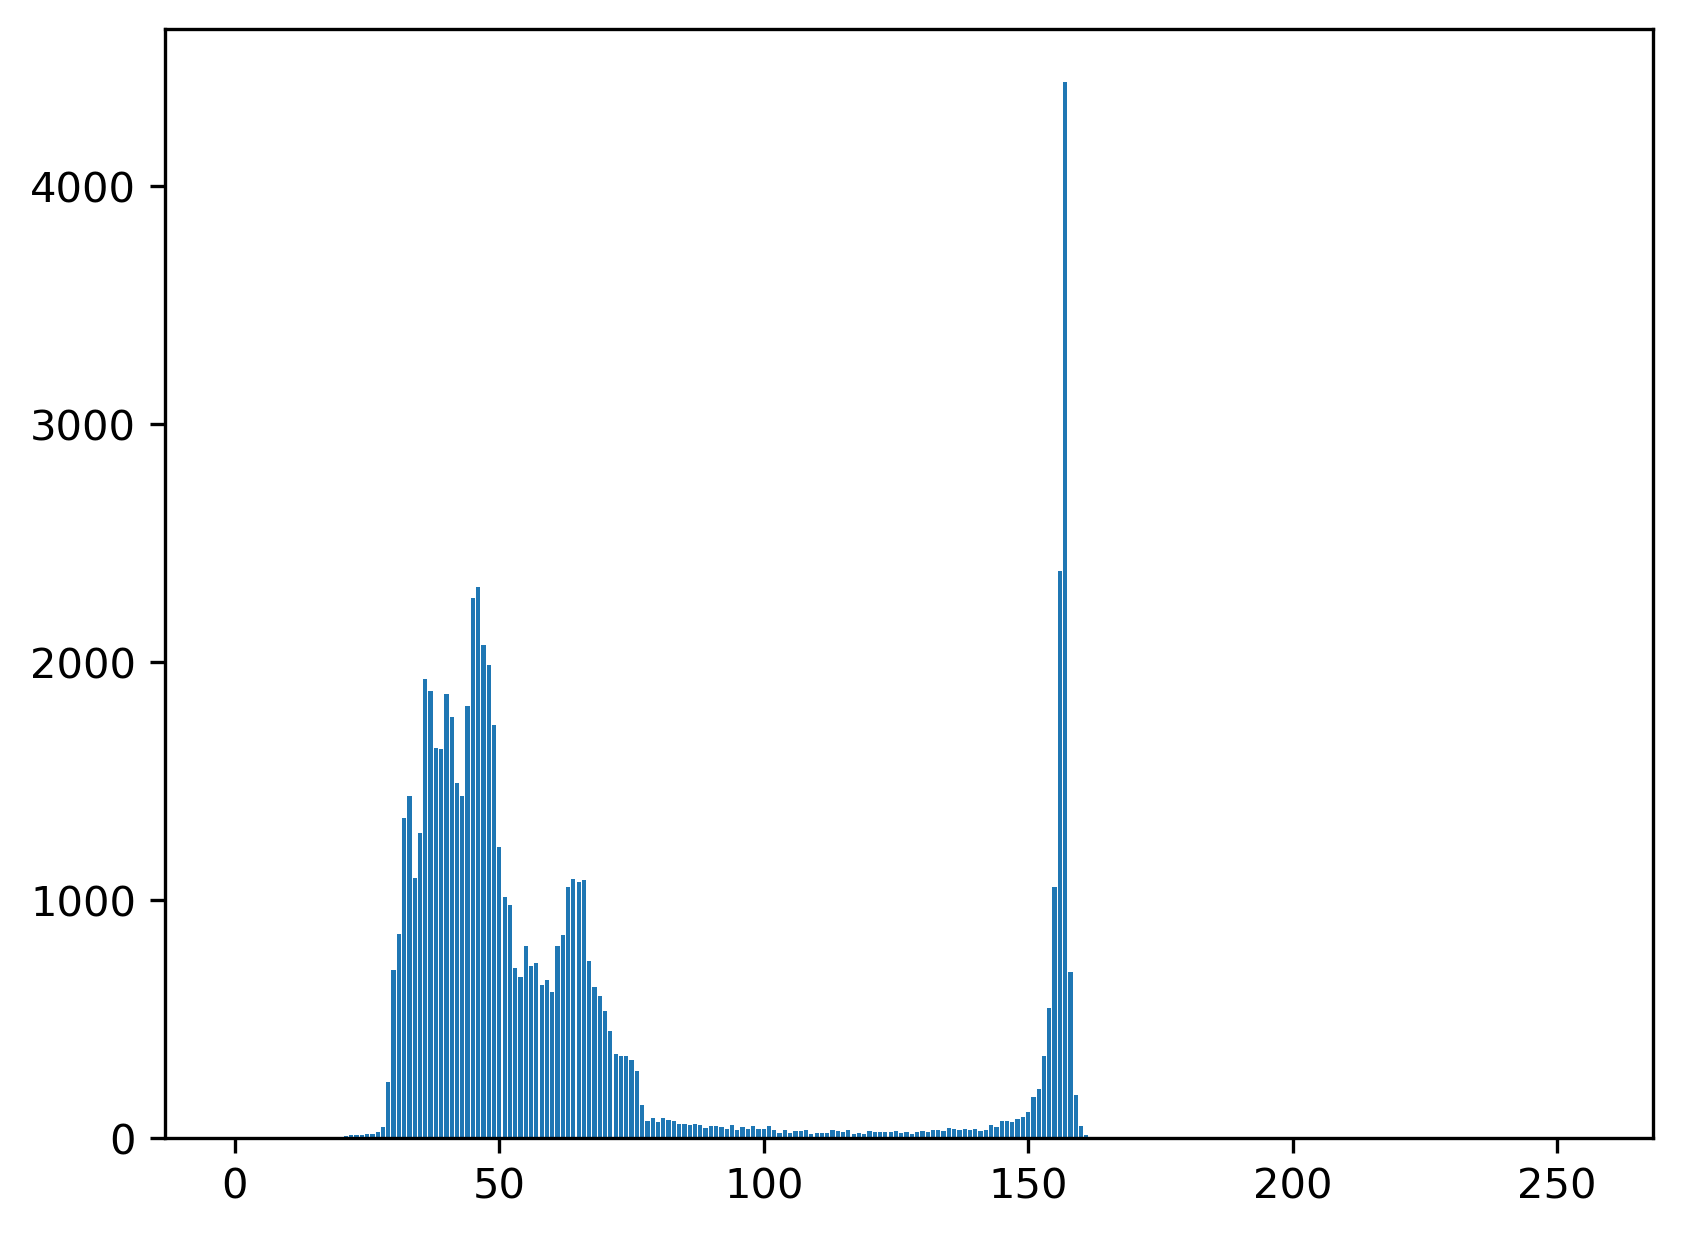

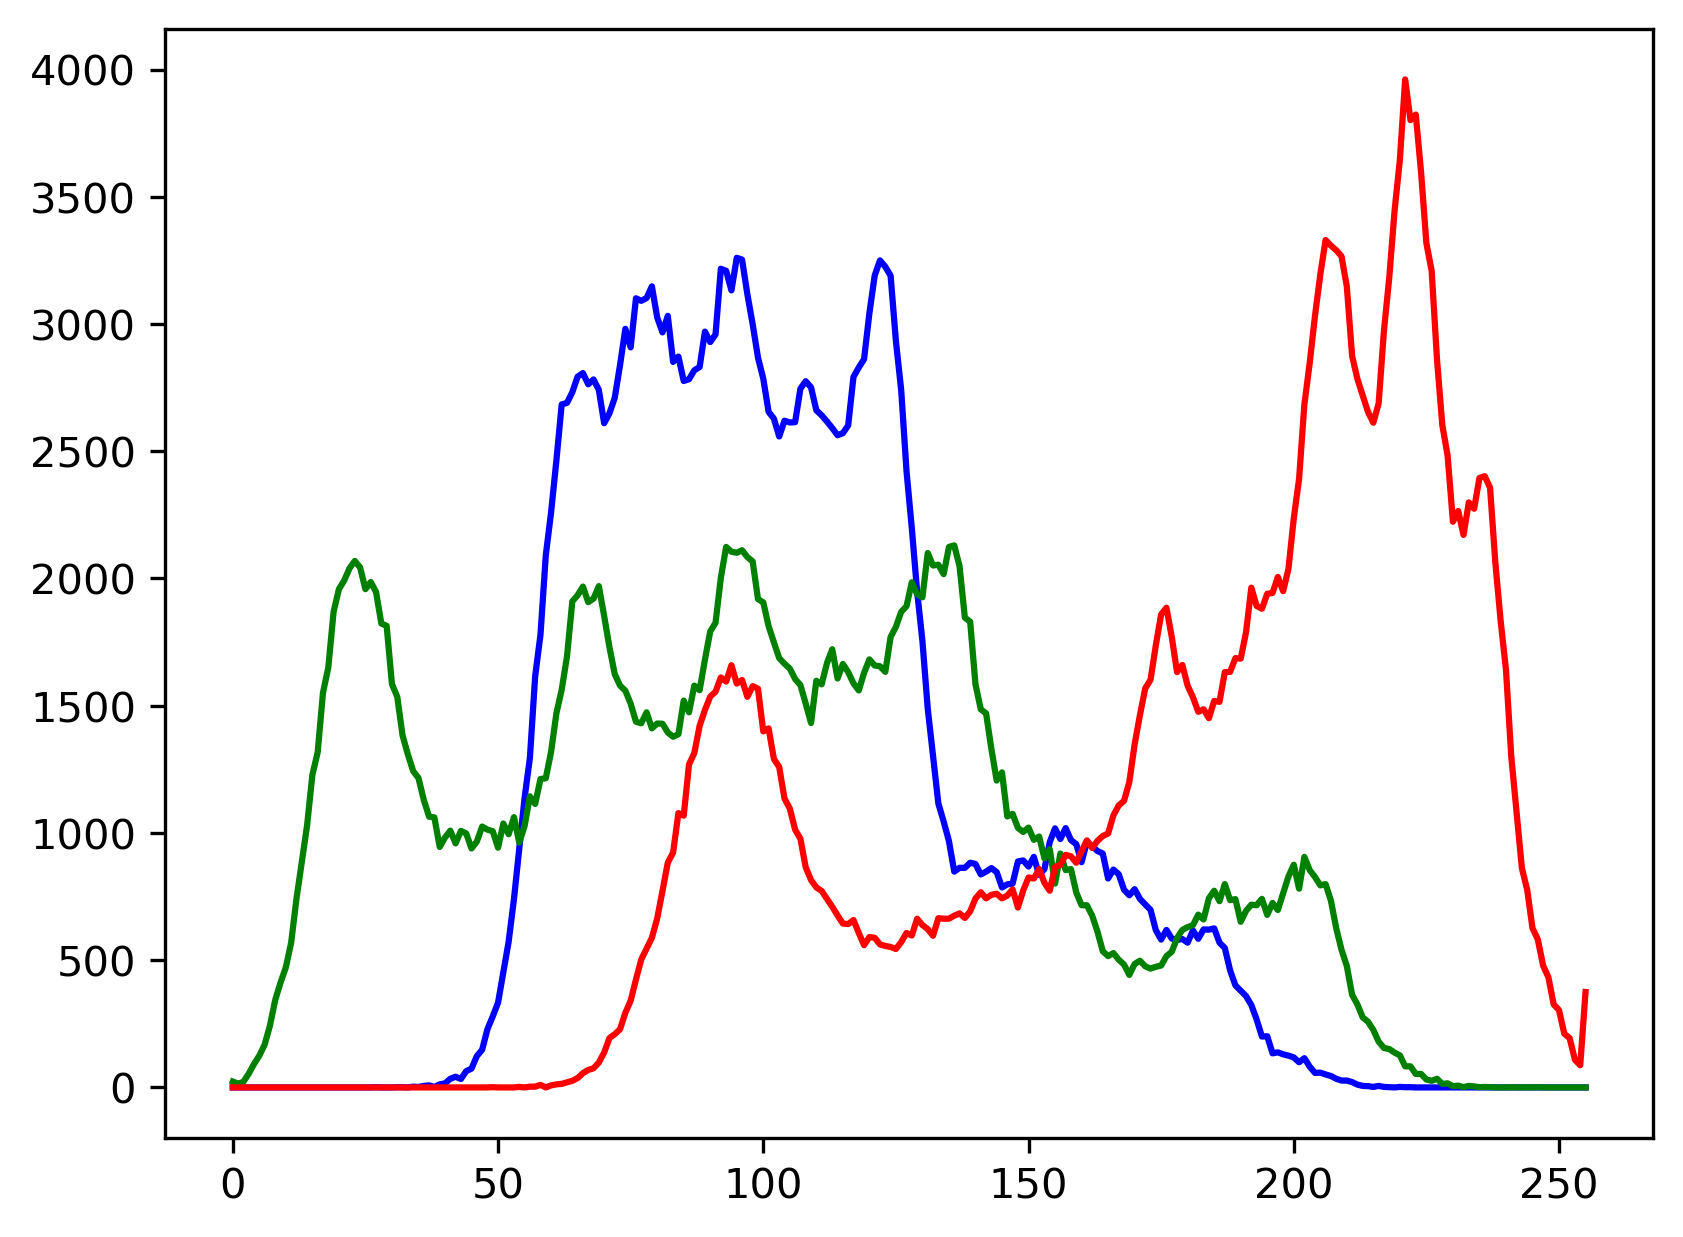

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image1 = cv2.imread('images/coin.jpg', cv2.IMREAD_GRAYSCALE)
hist = cv2.calcHist([image1], [0], None, [256], [0,256])
plt.figure(dpi=300)
plt.bar(np.arange(256), hist.flatten())
plt.show()

image2 = cv2.imread('images/lena.jpg', cv2.IMREAD_COLOR)
colors = ('b', 'g', 'r')
plt.figure(dpi=300)
for i in range(3):
    hist = cv2.calcHist([image2], [i], None, [256], [0,256])
    plt.plot(hist, color=colors[i])
plt.show()

cv2.waitKey(0)
cv2.destroyAllWindows()

---
2.2 이치화(binarization)
```python
cv2.threshold(src_image, threshold_value, max_value, flag) -> ret, dst_image
    - cv2.THRESH_BINARY
    - cv2.THRESH_BINARY_INV
    - cv2.THRESH_OTSU
```

In [16]:
import cv2

image = cv2.imread('images/coin.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)

ret, dst1 = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
cv2.imshow('result1', dst1)

ret, dst2 = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY_INV)
cv2.imshow('result2', dst2)

ret, dst3 = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU)
cv2.imshow('result3', dst3)
print('threshold value =', ret)

cv2.waitKey(0)
cv2.destroyAllWindows()

threshold value = 100.0


---
2.3 히스토그램 평활화(Histogram Equalization)
```python
cv2.equalizeHist(src_image) -> dst_image
    - src_image : 1 channel, 8 bit image
```

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/lena.jpg', cv2.IMREAD_COLOR)
cv2.imshow('image', image)

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
v = cv2.equalizeHist(v)    # for 1 channel, 8 bit image
hsv = cv2.merge([h, s, v])
image = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
cv2.imshow('result', image)

cv2.waitKey(0)
cv2.destroyAllWindows()

---
2.4 모폴로지 연산(Morphological Operation)

    - 기본연산
        - 침식(erode) 연산
        - 팽창(dilate) 연산
    - 응용연산
        - 열기(opening) : 침식(erode) -> 팽창(dilate)
        - 닫기(closing) : 팽창(dilate) -> 침식(erode)
        - Gradient      : 팽창(dilate) - 침식(erode)
        - TopHat        : image - 열기(opening)
        - BlackHat      : 닫기(closing) - image
    - 주요함수
```python
cv2.getStructuringElement(shape, ksize) -> kernel
cv2.erode(image, kernel, iterations) -> dst_image
cv2.dilate(image, kernel, iterations) -> dst_image
cv2.morphologyEx(image, op, kernel, iterations) -> dst_image
    - cv2.MORPH_ERODE, cv2.MORPH_DILATE
    - cv2.MORPH_OPEN, cv2.MORPH_CLOSE
    - cv2.MORPH_GRADIENT, cv2.MORPH_TOPHAT, cv2.MORPH_BLACKHAT
```


In [39]:
import cv2

image = cv2.imread('images/morphology.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)
ret, bin_img = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU)
cv2.imshow('bin_img', bin_img)

kernel = cv2.getStructuringElement(shape=cv2.MORPH_RECT, ksize=(3,3))
erode = cv2.erode(bin_img, kernel, iterations=2)
cv2.imshow('erode', erode)
dilate = cv2.dilate(erode, kernel, iterations=5)
cv2.imshow('dilate', dilate)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [52]:
import cv2

image = cv2.imread('images/morphology.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)
ret, bin_img = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU)
cv2.imshow('bin_img', bin_img)

# opening(erode -> dilate)
kernel = cv2.getStructuringElement(shape=cv2.MORPH_RECT, ksize=(3,3))
erode = cv2.morphologyEx(bin_img, cv2.MORPH_ERODE, kernel, iterations=2)
cv2.imshow('erode', erode)
dilate = cv2.morphologyEx(erode, cv2.MORPH_DILATE, kernel, iterations=5)
cv2.imshow('dilate', dilate)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [51]:
import cv2

image = cv2.imread('images/morphology.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)
ret, bin_img = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU)
cv2.imshow('bin_img', bin_img)

kernel = cv2.getStructuringElement(shape=cv2.MORPH_RECT, ksize=(3,3))
open = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel, iterations=1)
cv2.imshow('open', open)
close = cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, kernel, iterations=1)
cv2.imshow('close', close)
gradient = cv2.morphologyEx(bin_img, cv2.MORPH_GRADIENT, kernel, iterations=1)
cv2.imshow('gradient', gradient)

cv2.waitKey(0)
cv2.destroyAllWindows()

---
2.5 영역 레이블링(Region Labeling)
```python
cv2.connectedComponents(bin_img, connectivity) -> ret, labels
cv2.connectedComponentsWithStats(bin_img, connectivity) -> ret, labels, stats, centoids
```
    - connectivity : 연결성(4 또는 8)
    - ret : label의 개수
    - labels : label 정보로 이루어진 행렬(입력 이미지와 같은 크기)
    - stats : 각 region의 통계정보(x, y, width, height, area)
    - centroids : 각 region의 중심좌표

In [17]:
import cv2
import numpy as np

image = cv2.imread('images/shapes.bmp', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)
ret, bin_img = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU)
cv2.imshow('bin_img', bin_img)

ret, labels = cv2.connectedComponents(bin_img, connectivity=4)
print(ret) # label의 개수
print(labels) # label 정보로 이루어진 행렬(입력 이미지와 같은 크기)
# 컬러이미지로 레이블링 결과 출력
width, height = image.shape
dst_img = np.zeros((width, height, 3), dtype=np.uint8)
for i in range(ret):
    color = [int(j) for j in np.random.randint(0, 256, 3)]
    dst_img[labels == i] = color
cv2.imshow('dst_img', dst_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

7
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [27]:
import cv2
import numpy as np

image = cv2.imread('images/shapes.bmp', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)
ret, bin_img = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU)
cv2.imshow('bin_img', bin_img)

ret, labels, stats, centroids = cv2.connectedComponentsWithStats(bin_img, connectivity=4)
print(ret) # label의 개수
print(labels) # label 정보로 이루어진 행렬(입력 이미지와 같은 크기)
print(stats) # 각 region의 통계정보(x, y, width, height, area)
print(centroids) # 각 region의 중심좌표
# 컬러이미지로 레이블링 결과 출력
width, height = image.shape
dst_img = np.zeros((width, height, 3), dtype=np.uint8)
for i in range(1, ret):
    color = [int(j) for j in np.random.randint(0, 256, 3)]
    dst_img[labels == i] = color
    x, y, width, height, area = stats[i]
    cx, cy = centroids[i]
    cv2.rectangle(dst_img, (x,y), (x+width, y+height), (0,0,255), 1)
    cv2.circle(dst_img, (int(cx), int(cy)), 1, (0,0,0))
cv2.imshow('dst_img', dst_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

7
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[    0     0   256   256 48898]
 [   18    19    50    36  1423]
 [  164    28    73    50  3649]
 [   76    38    68    77  2339]
 [   59   105    51    61  1514]
 [  135   130    77    79  4715]
 [   18   211    82    37  2998]]
[[126.54229212 127.64507751]
 [ 42.80252987  36.63808855]
 [200.00986572  52.49328583]
 [114.91705857  76.48738777]
 [ 77.22457067 136.1010568 ]
 [172.82735949 169.46892895]
 [ 58.98632422 229.006004  ]]


---
### 3. 커널기반 필터링 / 직선, 원, 윤곽선 검출 및 영역 분할

3.1 일반적인 필터 연산

```python
cv2.filter2D(image, ddepth, kernel) -> dst_img
    ddepth : 이미지의 깊이(-1이면 입력영상과 동일)
    
<kernel 자동생성 방법>
    cv2.getGaussianKernel(ksize, sigma) -> ret
        ksize : kernel 크기
        sigma : 표준편차
        ret : 1차원이므로 2차원으로 만들기 위해서는 ret를 곱해서 사용
    cv2.getDerivKernels(dx, dy, ksize) -> kx, ky
        dx, dy : 미분의 order
        ksize : kernel의 크기
        kx, ky : 1차원이므로 2차원으로 만들기 위해서는 ret를 곱해서 사용
```

In [24]:
import cv2
import numpy as np

image = cv2.imread('images/lena.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)

# 평균값 필터
kernel1 = np.array([[1, 1, 1],
                    [1, 1, 1], 
                    [1, 1, 1]]) * (1/9)    # kernel의 합이 1이 되도록 조정
# 가우시안 블러 필터
ret = cv2.getGaussianKernel(ksize=3, sigma=0.5) # 1차원
print(ret @ ret.T)
# 미분 필터
kx, ky = cv2.getDerivKernels(dx=0, dy=2, ksize=3) # 1차원, dx, dy는 미분 order 지정
print(kx)
print(kx @ kx.T)
print(ky)
print(ky @ ky.T)

dst_img = cv2.filter2D(image, -1, kernel1) # ddepth가 -1이면 입력영상과 동일
cv2.imshow('dst_img', dst_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

[[0.01134374 0.08381951 0.01134374]
 [0.08381951 0.61934703 0.08381951]
 [0.01134374 0.08381951 0.01134374]]
[[1.]
 [2.]
 [1.]]
[[1. 2. 1.]
 [2. 4. 2.]
 [1. 2. 1.]]
[[ 1.]
 [-2.]
 [ 1.]]
[[ 1. -2.  1.]
 [-2.  4. -2.]
 [ 1. -2.  1.]]


---
3.2 블러 필터 및 미디언 필터

(1) box filter : 커널 ksize=(c,r) 크기의 평균 필터링
```python
cv2.boxFilter(image, ddepth, ksize) -> dst_img
```
(2) median filter : 커널 ksize=s 크기의 미디언 필터링
```python
cv2.medianBlur(image, ksize) -> dst_img
```
(3) Gaussian filter : 커널 ksize=(c,r) 크기와 x축 표준편차, y축 표준편차을 이용한 필터링
```python
cv2.GaussianBlur(image, ksize, sigmaX, sigmaY) -> dst_img
```

In [32]:
import cv2
import numpy as np

image = cv2.imread('images/lena.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)

dst_img = cv2.boxFilter(image, -1, ksize=(5,5))
cv2.imshow('dst_img(box)', dst_img)

dst_img = cv2.medianBlur(image, ksize=3)
cv2.imshow('dst_img(median)', dst_img)

dst_img = cv2.GaussianBlur(image, ksize=(9,9), sigmaX=0.5, sigmaY=0.5)
cv2.imshow('dst_img(Gaussian)', dst_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

---
3.3 미분필터

(1) Sobel filter  
(2) Laplacian filter

In [55]:
import cv2
import numpy as np

image = cv2.imread('images/shapes.bmp', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)

# Sobel 연산자
# X축 gradient 계산 및 정규화
gx = cv2.Sobel(image, cv2.CV_32F, dx=1, dy=0, ksize=3)
dstX = cv2.sqrt(np.abs(gx))
dstX = cv2.normalize(dstX, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
cv2.imshow('Sobel-dstX', dstX)
# Y축 gradient 계산 및 정규화
gy = cv2.Sobel(image, cv2.CV_32F, dx=0, dy=1, ksize=3)
dstY = cv2.sqrt(np.abs(gy))
dstY = cv2.normalize(dstY, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
cv2.imshow('Sobel-dstY', dstY)
# X축과 Y축 gradient 합성
mag = cv2.magnitude(gx, gy)
dstM = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
cv2.imshow('Sobel-dstM', dstM)

# Laplacian 연산자
dst_img = cv2.Laplacian(image, -1, ksize=3)
cv2.imshow('Laplacian', dst_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

---
3.4 캐니 에지(Canny edge) 검출

In [4]:
import cv2
import numpy as np

image = cv2.imread('images/lena.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', image)

# OTSU 방법을 이용한 임계치 설정
th, dst = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
low, high = th*0.5, th*1.5
print(f"low = {low}, high = {high}")
# Canny edge 검출
dst_img = cv2.Canny(image, low, high)
cv2.imshow('dst_img', dst_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

low = 58.5, high = 175.5


---
3.5 Hough Transform
```python
cv2.HoughLines(edge_img, rho, theta, threshold)
cv2.HoughLinesP(edge_img, rho, theta, threshold)
    rho : rho의 간격
    theta : theta의 간격
    threshold : line의 길이 임계값
```

In [25]:
import cv2
import numpy as np

src_image = cv2.imread('images/poly_bw.jpg', cv2.IMREAD_COLOR)
image = cv2.cvtColor(src_image, cv2.COLOR_BGR2GRAY)

# Canny edge 검출
edge_img = cv2.Canny(image, 50, 100)
cv2.imshow('edge_img', edge_img)
# Hough Line 검출
lines = cv2.HoughLines(edge_img, rho=1.0, theta=np.pi/180, threshold=70)
if(lines is None): print("None")
print(lines.shape)
for line in lines:
    rho, theta = line[0]
    c = np.cos(theta)
    s = np.sin(theta)
    x0, y0 = rho * c, rho * s    # x, y 절편
    sx, sy = int(x0 + 1000 * (-s)), int(y0 + 1000 * c)
    ex, ey = int(x0 - 1000 * (-s)), int(y0 - 1000 * c)
    cv2.line(src_image, (sx,sy), (ex,ey), (0,0,255), 1)

cv2.imshow('image', src_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

(8, 1, 2)


In [24]:
import cv2
import numpy as np

src_image = cv2.imread('images/poly_bw.jpg', cv2.IMREAD_COLOR)
image = cv2.cvtColor(src_image, cv2.COLOR_BGR2GRAY)

# Canny edge 검출
edge_img = cv2.Canny(image, 50, 100)
cv2.imshow('edge_img', edge_img)
# Hough Line 검출
lines = cv2.HoughLinesP(edge_img, rho=1.0, theta=np.pi/180, threshold=10)
if(lines is None): print("None")
print(lines.shape)
for line in lines:
    sx, sy, ex, ey = line[0]
    cv2.line(src_image, (sx,sy), (ex,ey), (0,0,255), 2)

cv2.imshow('image', src_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

(65, 1, 4)


---
3.6 윤곽선(contour) 검출 및 그리기

In [1]:
import cv2
import numpy as np

src_image = cv2.imread('images/poly_bw.jpg', cv2.IMREAD_COLOR)
gray_image = cv2.cvtColor(src_image, cv2.COLOR_BGR2GRAY)
th, bin_img = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("# of contour = ", len(contours))
cv2.drawContours(src_image, contours, -1, (0,0,255))
cv2.imshow('src_image', src_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

# of contour =  3


In [2]:
import cv2
import numpy as np

src_image = cv2.imread('images/pic3.png', cv2.IMREAD_COLOR)
gray_image = cv2.cvtColor(src_image, cv2.COLOR_BGR2GRAY)
th, bin_img = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2.imshow('bin_img', bin_img)

contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
print("# of contour = ", len(contours))
print("hierarchy =\n", hierarchy, sep='') # [next, previous, child, parent]
cv2.drawContours(src_image, contours, -1, (0,0,255))
cv2.imshow('src_image', src_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

# of contour =  9
hierarchy =
[[[ 1 -1 -1 -1]
  [ 2  0 -1 -1]
  [ 3  1 -1 -1]
  [ 4  2 -1 -1]
  [-1  3  5 -1]
  [ 6 -1 -1  4]
  [ 7  5 -1  4]
  [ 8  6 -1  4]
  [-1  7 -1  4]]]


---
3.7 피라미드 기반 분할
```python
cv2.pyrMeanShiftFiltering(image, sp, sr, maxLevel) -> dst_image
```

    - image : color image
    - sp : MeanShift를 위한 공간 윈도우의 반지름
$$ X-sp \le x \le X+sp \qquad Y-sp \le y \le Y+sp $$

    - sr : MeanShift를 위한 컬러 윈도우의 반지름.
        - (R,G,B)는 (X,Y)좌표의 컬러
        - (r,g,b)는 (x,y)좌표의 컬러
$$ \Vert(R,G,B) - (r,g,b)\Vert \le sr $$

    - maxLevel : 피라미드의 최대 레벨(maxLevel + 1의 가우시안 피라미드 생성)

In [71]:
import cv2
import numpy as np

image = cv2.imread('images/Citrus.jpg', cv2.IMREAD_COLOR)
cv2.imshow('image', image)

dst_img = cv2.pyrMeanShiftFiltering(image, sp=5, sr=20, maxLevel=4)
cv2.imshow('dst_img', dst_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

3.8 모양관련 특징 검출

- contour에 의한 물체의 shape과 관련된 특징을 검출

In [21]:
import cv2
import numpy as np

src_image = cv2.imread('images/coin.jpg', cv2.IMREAD_COLOR)
gray_image = cv2.cvtColor(src_image, cv2.COLOR_BGR2GRAY)
th, bin_img = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("# of contour = ", len(contours))
# cv2.drawContours(src_image, contours, -1, (0,255,0))
for contour in contours:
    area = cv2.contourArea(contour)  # 면적 계산
    if area > 200:
        print(f"area of shape = {area}")
        x, y, w, h = cv2.boundingRect(contour)  # 바운딩 사각형
        cv2.rectangle(src_image, (x,y), (x+w, y+h), (0,0,255), 1)
cv2.imshow('src_image', src_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

# of contour =  23
area of shape = 1673.5
area of shape = 2142.5
area of shape = 1747.0
area of shape = 1091.0
area of shape = 1545.0
area of shape = 1993.5
area of shape = 1006.5


---
## 4. 비디오 처리

4.1 비디오 출력하기

In [69]:
import cv2

cap = cv2.VideoCapture("videos/vtest.avi")
if not cap.isOpened():
    raise RuntimeError(f"비디오를 열 수 없습니다: {video_path}")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imshow("Video", frame)
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

4.2 비디오로 부터 배경이미지 추출하고 저장하기

In [65]:
import cv2
import numpy as np

video_path = "videos/cup.mp4"
output_path = "videos/bg_median_cup.jpg"

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"비디오를 열 수 없습니다: {video_path}")

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if frame_count == 0:
    raise RuntimeError("프레임 수를 읽을 수 없습니다.")

sample_count = min(100, frame_count)
sample_indices = np.linspace(0, frame_count-1, sample_count, dtype=np.int32)

frames = []
for idx in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ret, frame = cap.read()
    if not ret:
        continue
    frames.append(frame)
cap.release()

if len(frames) == 0:
    raise RuntimeError("샘플 프레임을 읽지 못했습니다.")

median_frame = np.median(np.stack(frames, axis=0), axis=0).astype(np.uint8)

cv2.imwrite(output_path, median_frame)
cv2.imshow("Background(Median)", median_frame)
cv2.waitKey(0)
cv2.destroyAllWindows()

print(f"샘플 프레임 수: {len(frames)}")
print(f"저장 완료: {output_path}")

샘플 프레임 수: 100
저장 완료: videos/bg_median_cup.jpg


---
4.3 배경과 전경 분할

- 미리 준비된 배경이미지와의 차영상을 통한 전경분할
- 배경모델의 갱신과 이동물체의 검출

```python
cv2.bgsegm.createBackgroundSubtractorMOG([, history[, nmixtures[, backgroundRatio[, noiseSigma]]]]) -> bgMOG
```

        - history : 배경모델 생성에 사용되는 frame의 개수(기본:200)
        - nmixtures : 배경모델 생성에 사용되는 Gaussian model의 개수(기본:5)
        - backgroudRatio : 배경영역의 비율(기본:0.7)
        - noiseSigma : 잡음성분 표준편차(기본:0)
    
```python
bgMOG.apply(frame[, fgmask[, learningRate]]) -> fgmask
```

        - frame : 입력 frame
        - fgmask : output foreground mask(8-bit binary image)
        - learningRate : 학습률로 0~1사이의 값(기본:-1). 0:기존모델사용, 1:새로학습, -1:자동

In [75]:
import numpy as np 
import cv2 

# 배경이미지
bg_img = cv2.imread("videos/bg_median_vtest.jpg", cv2.IMREAD_COLOR)

# 비디오파일 읽기
cap = cv2.VideoCapture("videos/vtest.avi")
if not cap.isOpened():
    raise RuntimeError(f"비디오를 열 수 없습니다: {video_path}")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: 
        break
        
    # 배경과의 차영상으로 부터 전경이미지 만들기
    diff_img = cv2.absdiff(frame, bg_img)
    b, g, r = cv2.split(diff_img)
    ret, b = cv2.threshold(b, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    ret, g = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    ret, r = cv2.threshold(r, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    fg_img = cv2.bitwise_or(b, g)
    fg_img = cv2.bitwise_or(r, fg_img)
    
    fg_img = cv2.erode(fg_img, None, 5)
    fg_img = cv2.dilate(fg_img, None, 5)
    fg_img = cv2.erode(fg_img, None, 8)

    # 전경이미지의 객체 추출
    contours, hierarchy = cv2.findContours(fg_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(frame, contours, -1, (255,0,0), 1)
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 80:
            x, y, w, h = cv2.boundingRect(contour)  # 바운딩 사각형
            cv2.rectangle(frame, (x,y), (x+w, y+h), (0,0,255), 2)

    cv2.imshow("diff_frame", fg_img)
    cv2.imshow("frame", frame)
    
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()        

In [71]:
import numpy as np 
import cv2 

cap = cv2.VideoCapture("videos/vtest.avi")
if not cap.isOpened():
    raise RuntimeError(f"비디오를 열 수 없습니다")

# 배경제거 객체 생성
bgMOG = cv2.bgsegm.createBackgroundSubtractorMOG(history=300) # history : 배경모델에 사용되는 프레임의 수

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: 
        break
    # 배경모델 갱신 및 이동객체 추출
    fg_img = bgMOG.apply(frame, learningRate=-1) # learningRate(0:기존모델사용, 1:새로학습, -1:자동)

    cv2.imshow("frame", frame)
    cv2.imshow("objects", fg_img)
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

---
4.4 광류(Optical Flow)  

    - 밝기 패턴의 이동
    - 영상의 각 화소에 속도벡터(velocity vector)를 할당
```python
cv2.calcOpticalFlowPyrLK(prevImg, nextImg, prevPts, nextPts, status, err, wirnSize, maxLevel, criteria, flags, minEigThreshold) -> nextPts, status, err
```
    - prevImg: 이전 프레임 영상
    - nextImg: 다음 프레임 영상
    - prevPts: 이전 프레임의 코너 특징점, cv2.goodFeaturesToTrack()으로 검출
    - nextPst: 다음 프레임에서 이동한 코너 특징점
    - status: 결과 상태 벡터, nextPts와 같은 길이, 대응점이 있으면 1, 없으면 0
    - err: 결과 에러 벡터, 대응점 간의 오차
    - winSize=(21,21): 각 이미지 피라미드의 검색 윈도 크기
    - maxLevel=3: 이미지 피라미드 계층 수
    - criteria=(COUNT+EPS, 30, 0.01): 반복 탐색 중지 요건
        - cv2.TERM_CRITERIA_EPS: 정확도가 epsilon보다 작으면 중지
        - cv2.TERM_CRITERIA_MAX_ITER: max_iter 횟수를 채우면 중지
        - cv2.TERM_CRITERIA_COUNT: MAX_ITER와 동일
        - max_iter: 최대 반복 횟수
        - epsilon: 최소 정확도
    - flgs=0: 연산 모드
        - 0: prevPts를 nextPts의 초기 값으로 사용
        - cv2.OPTFLOW_USE_INITAL_FLOW: nextPts의 값을 초기 값으로 사용
        - cv2.OPTFLOW_LK_GET_MIN_EIGENVALS: 오차를 최소 고유 값으로 계산
    - minEigThreshold=1e-4: 대응점 계산에 사용할 최소 임계 고유 값

```python
cv2.calcOpticalFlowFarneback(prev, next, flow, pyr_scale, levels, winsize, iterations, poly_n, poly_sigma, flags) -> flow
```
    - prev, next: 이전, 이후 프레임
    - flow: 광학 흐름 계산 결과, 각 픽셀이 이동한 거리 (입력과 동일한 크기)
    - pyr_scale: 이미지 피라미드 스케일
    - levels: 이미지 피라미드 개수
    - winsize: 평균 윈도 크기
    - iterations: 각 피라미드에서 반복할 횟수
    - poly_n: 다항식 근사를 위한 이웃 크기, 5 또는 7
    - poly_sigma: 가우시안 시그마(poly_n=5일 때는 1.1, poly_n=7일 때는 1.5)
    - flags: 연산 모드
        - cv2.OPTFLOW_USE_INITAL_FLOW: flow 값을 초기 값으로 사용
        - cv2.OPTFLOW_FARNEBACK_GAUSSIAN: 박스 필터 대신 가우시안 필터 사용

In [17]:
import numpy as np 
import cv2 

cap = cv2.VideoCapture("videos/slow.mp4")
if not cap.isOpened():
    raise RuntimeError(f"비디오를 열 수 없습니다")

# 첫 frame을 로드하고 특징점을 추출
ret, frame = cap.read()
prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(prev_gray, maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)
# print('p0.shape =', p0.shape)

color = np.random.randint(0, 255, size=(100,3)) # random colors
mask = np.zeros_like(frame) # line을 그리기 위한 배열

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: 
        break
    # 현재 frame과 이전 frame을 이용하여 optical flow를 계산
    curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    p1, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prevPts=p0, nextPts=None,
                                               winSize=(15,15), maxLevel=7)
    good_p0 = p0[status==1]  # 성공적으로 검출된 특징점만...
    good_p1 = p1[status==1]

    for i, (new, old) in enumerate(zip(good_p1, good_p0)):
        nx, ny = int(new[0]), int(new[1])
        ox, oy = int(old[0]), int(old[1])
        cv2.line(mask, (nx,ny), (ox,oy), color[i].tolist(), 2) # line을 mask에 그리기
        cv2.circle(frame, (nx,ny), 5, color[i].tolist(), -1)

    frame = cv2.add(frame, mask)  # line을 frame에 표시
    cv2.imshow("frame", frame)
    
    if cv2.waitKey(30) & 0xFF == 27:
        break

    # 현재 frame을 이전 frame으로 복사
    prev_gray = curr_gray.copy()
    p0 = good_p1.reshape(-1,1,2)

cap.release()
cv2.destroyAllWindows()

In [19]:
import numpy as np 
import cv2 

def drawFlow(img, flow, th=2, stride=8):
    h, w = img.shape[:2]
    mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
    flow2 = np.int32(flow)
    for y in range(0, h, stride):
        for x in range(0, w, stride):
            dx, dy = flow2[y, x]
            if mag[y, x] > th:
                cv2.circle(img, (x,y), 2, (255,0,0), -1)
                cv2.line(img, (x,y), (x+dx, y+dy), (0,255,0), 1)

cap = cv2.VideoCapture("videos/vtest.avi")
if not cap.isOpened():
    raise RuntimeError(f"비디오를 열 수 없습니다")

# 첫 frame을 로드하고 그레이로 변환
ret, frame = cap.read()
prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: 
        break
    next_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(prev_gray, next_gray, None, 
                                        pyr_scale=0.5, levels=3, winsize=15, 
                                        iterations=3, poly_n=5, poly_sigma=1.2, 
                                        flags=cv2.OPTFLOW_FARNEBACK_GAUSSIAN)
    drawFlow(frame, flow, th=2, stride=8)

    cv2.imshow("frame", frame)
    prev_gray = next_gray
    
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

---
4.5 MeanShift / CamShift 추적

    - 물체의 히스토그램 역투영을 이용하여 이동물체를 추적
    - MeanShift는 이동물체의 크기변화 없이 주어진 윈도우 크기대로 물체의 중심점을 추적
    - CamShift는 이동물체의 중심점, 크기, 회전 등을 함께 추적

In [39]:
import numpy as np 
import cv2 

cap = cv2.VideoCapture("videos/cup.mp4")
if not cap.isOpened():
    raise RuntimeError(f"비디오를 열 수 없습니다")

# 첫번째 frame을 열고 마우스로 ROI 선택
ret, frame = cap.read()
rc = cv2.selectROI("Select Tracking Object", frame, True)
print(rc) # rc = (x, y, w, h)
roi = frame[rc[1]:rc[1]+rc[3], rc[0]:rc[0]+rc[2]]
# HS 히스토그램 계산(hsv 이미지로 부터 h, s만...)
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
hist = cv2.calcHist([roi_hsv], [0,1], None, [90,128], [0,180,0,256])

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: 
        break

    # 히스토그램 역투영
    frame_hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    backproj = cv2.calcBackProject([frame_hsv], channels=[0,1], hist=hist, ranges=[0,180,0,256], scale=1)
    # MeanShift / CamShift 추적
    ret, rc = cv2.CamShift(backproj, rc, criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT, 10, 0.6))
    # 추적결과 그리기
    cv2.rectangle(frame, rc, (0,0,255), 2)
    cv2.imshow("frame", frame)
    
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

(306, 121, 110, 268)
